# analysis_b / 01 — Data Preparation

Full processing pipeline, self-contained. Loads the raw scraper CSV, cleans text, lemmatizes with spaCy `en_core_web_lg`, engineers temporal features including a **day-level time index**, and writes the cleaned parquet that all other analysis_b notebooks consume.

**Reads:** `../reddit_scrapy/data/v1_r/3month_new_posts_Dec2025-March2026.csv`  
**Writes:** `artifacts/posts_clean.parquet`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import spacy
import re
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
%matplotlib inline

DATA_PATH = Path('../reddit_scrapy/data/Paranormal_20250101_20251231_timerange.csv')
ARTIFACTS  = Path('artifacts')
ARTIFACTS.mkdir(exist_ok=True)

MIN_TOKENS = 5  # drop posts with fewer lemma tokens than this after spaCy

## 1. Load & Inspect

In [2]:
df_raw = pd.read_csv(DATA_PATH)
print(f'Shape   : {df_raw.shape}')
print(f'Columns : {df_raw.columns.tolist()}')
df_raw.head(3)

Shape   : (105755, 12)
Columns : ['type', 'post_id', 'post_title', 'comment_id', 'author', 'text', 'score', 'depth', 'num_comments', 'url', 'permalink', 'created_utc']


,type,post_id,post_title,comment_id,author,text,score,depth,num_comments,url,permalink,created_utc
0,post,1kq7oa6,Massage therapist,NaN,Significant-Eye-6367,NaN,1,-1,2.0,https://i.redd.it/yiepn9jsmp1f1.jpeg,https://reddit.com/r/Paranormal/comments/1kq7o...,2025-05-19 09:46:48
1,comment,1kq7oa6,Massage therapist,mt3ggl8,AutoModerator,Remember to change your flair to reflect the a...,1,0,NaN,NaN,https://reddit.com/r/Paranormal/comments/1kq7o...,2025-05-19 09:46:53
2,comment,1kq7oa6,Massage therapist,mt3ggf3,AutoModerator,"In an effort to improve submission quality, we...",1,0,NaN,NaN,https://reddit.com/r/Paranormal/comments/1kq7o...,2025-05-19 09:46:50


## 2. Column Standardization

In [3]:
COLUMN_MAP = {
    'selftext'       : 'text',
    'body'           : 'text',
    'post_text'      : 'text',
    'score'          : 'score',
    'ups'            : 'score',
    'link_flair_text': 'flair',
    'flair'          : 'flair',
    'post_flair'     : 'flair',
    'created_utc'    : 'created_utc',
    'created'        : 'created_utc',
    'timestamp'      : 'created_utc',
    'id'             : 'post_id',
    'post_id'        : 'post_id',
    'title'          : 'title',
}

df = df_raw.rename(columns={k: v for k, v in COLUMN_MAP.items() if k in df_raw.columns})

required = ['text', 'created_utc']
missing  = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(
        f'Missing required columns after rename: {missing}.\n'
        f'Available columns: {df.columns.tolist()}\n'
        f'Update COLUMN_MAP above to match your CSV headers.'
    )

for col, default in [('score', np.nan), ('flair', 'unknown'), ('title', ''), ('post_id', None)]:
    if col not in df.columns:
        df[col] = default

print('Standardized columns:', df.columns.tolist())
print(f'Total rows: {len(df):,}')

Standardized columns: ['type', 'post_id', 'post_title', 'comment_id', 'author', 'text', 'score', 'depth', 'num_comments', 'url', 'permalink', 'created_utc', 'flair', 'title']
Total rows: 105,755


## 3. Metadata Overview

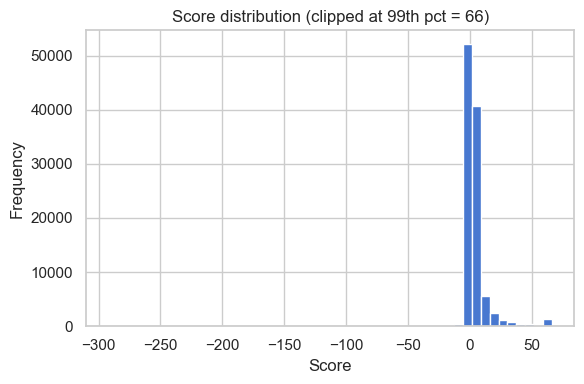

count    105755.000000
mean          5.378715
std          25.212371
min        -292.000000
25%           1.000000
50%           2.000000
75%           3.000000
max        2670.000000
Name: score, dtype: float64


In [4]:
if df['score'].notna().any():
    cap = df['score'].quantile(0.99)
    fig, ax = plt.subplots(figsize=(6, 4))
    df['score'].clip(upper=cap).plot(kind='hist', bins=50, ax=ax)
    ax.set_title(f'Score distribution (clipped at 99th pct = {cap:.0f})')
    ax.set_xlabel('Score')
    plt.tight_layout()
    plt.show()
    print(df['score'].describe())
else:
    print('No score data available.')

## 4. Text Cleaning

Strip Reddit-specific markup. Original text preserved in `text_raw`.

In [5]:
def clean_text(text):
    if not isinstance(text, str) or not text.strip():
        return ''
    if text.strip().lower() in ('[deleted]', '[removed]'):
        return ''
    text = re.sub(r'(?m)^>.*$', '', text)           # blockquotes
    text = re.sub(r'https?://\S+|www\.\S+', '', text) # URLs
    text = re.sub(r'\[([^\]]+)\]\([^\)]*\)', r'\1', text)  # markdown links
    text = re.sub(r'\*{1,3}([^*]+)\*{1,3}', r'\1', text)  # bold/italic
    text = re.sub(r'~~([^~]+)~~', r'\1', text)      # strikethrough
    text = re.sub(r'```[\s\S]*?```', '', text)       # fenced code
    text = re.sub(r'`[^`]+`', '', text)              # inline code
    text = re.sub(r'(?m)^#{1,6}\s', '', text)        # ATX headers
    text = re.sub(r'\bu/\w+', '', text)              # user mentions
    text = re.sub(r'\br/\w+', '', text)              # subreddit mentions
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

df['text_raw']   = df['text'].copy()
df['text_clean'] = df['text_raw'].apply(clean_text)

before = len(df)
df = df[df['text_clean'].str.len() > 0].reset_index(drop=True)
print(f'Dropped {before - len(df):,} empty/deleted posts. Remaining: {len(df):,}')

Dropped 6,688 empty/deleted posts. Remaining: 99,067


In [6]:
# Most frequent authors
print(df['author'].value_counts().head(20))


author
AutoModerator          9003
[deleted]              7157
Jack_Shid              1160
Same_Version_5216       679
SpotMiserable3379       586
Illustrious-Bat1553     492
Leading-Bug-Bite        471
WishboneSenior5859      397
Pale_Natural9272        288
Learner421              281
strafekun               278
wsup1974                251
Randie_Butternubs       248
pandora_ramasana        230
Competativebad925       226
MrBones_Gravestone      221
punkineo                198
DaniGirlOK              197
AlekHidell1122          195
bizoticallyyours83      195
Name: count, dtype: int64


In [6]:
# Drop AutoModerator posts
before = len(df)
df = df[df['author'] != 'AutoModerator'].reset_index(drop=True)
print(f'Dropped {before - len(df):,} AutoModerator posts. Remaining: {len(df):,}')


Dropped 9,003 AutoModerator posts. Remaining: 90,064


## 5. spaCy Lemmatization

Pipeline: tokenize → POS-filter (NOUN, VERB, ADJ, ADV) → remove stopwords and short tokens → lemmatize. Posts below `MIN_TOKENS` after this step are dropped.

In [9]:
pip install https://github.com/explosion/spacy-models/releases/download/en_core_web_lg-3.8.0/en_core_web_lg-3.8.0-py3-none-any.whl


  Using cached https://github.com/explosion/spacy-models/releases/download/en_core_web_lg-3.8.0/en_core_web_lg-3.8.0-py3-none-any.whl (400.7 MB)
Note: you may need to restart the kernel to use updated packages.


In [10]:
nlp = spacy.load('en_core_web_lg')
nlp.select_pipes(enable=['tok2vec', 'tagger', 'attribute_ruler', 'lemmatizer'])

KEEP_POS = {'NOUN', 'VERB', 'ADJ', 'ADV'}

def extract_tokens(doc):
    return [
        token.lemma_.lower()
        for token in doc
        if  token.pos_  in KEEP_POS
        and not token.is_stop
        and not token.is_punct
        and not token.like_num
        and not token.is_space
        and len(token.lemma_) > 2
    ]

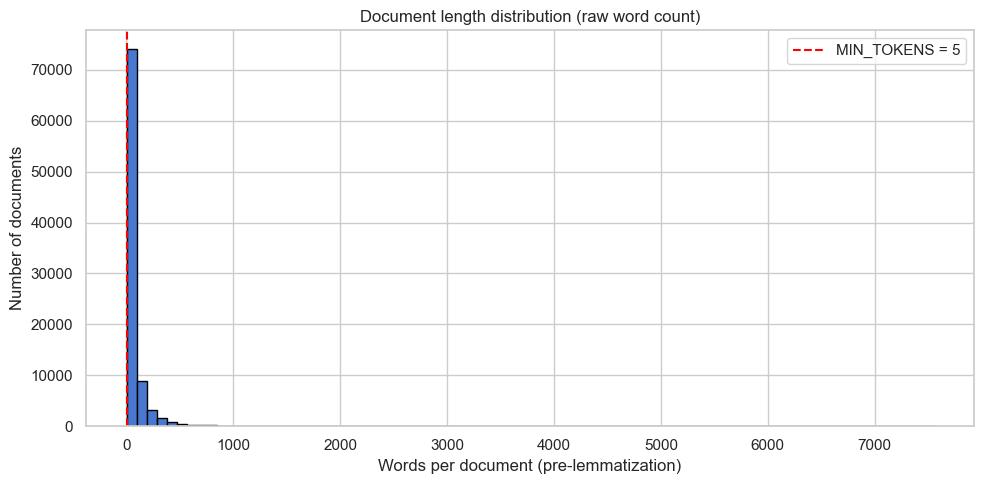

count    90064.000000
mean        65.546067
std        124.411763
min          1.000000
25%         10.000000
50%         27.000000
75%         67.000000
max       7551.000000
Name: text_clean, dtype: float64

Docs below MIN_TOKENS=5: 8,756 (9.7%)


In [11]:
raw_word_count = df['text_clean'].str.split().apply(len)

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(raw_word_count, bins=80, edgecolor='black')
ax.axvline(MIN_TOKENS, color='red', linestyle='--', label=f'MIN_TOKENS = {MIN_TOKENS}')
ax.set_xlabel('Words per document (pre-lemmatization)')
ax.set_ylabel('Number of documents')
ax.set_title('Document length distribution (raw word count)')
ax.legend()
plt.tight_layout()
plt.show()

print(raw_word_count.describe())
print(f'\nDocs below MIN_TOKENS={MIN_TOKENS}: {(raw_word_count < MIN_TOKENS).sum():,} ({(raw_word_count < MIN_TOKENS).mean():.1%})')


In [12]:
BATCH_SIZE = 64
texts      = df['text_clean'].tolist()

all_tokens = [
    extract_tokens(doc)
    for doc in nlp.pipe(texts, batch_size=BATCH_SIZE)
]

df['tokens']      = all_tokens
df['text_lemma']  = df['tokens'].apply(' '.join)
df['token_count'] = df['tokens'].apply(len)

before = len(df)
df = df[df['token_count'] >= MIN_TOKENS].reset_index(drop=True)
print(f'Dropped {before - len(df):,} posts below {MIN_TOKENS}-token floor. Remaining: {len(df):,}')
print(f'Median token count: {df["token_count"].median():.0f}')

Dropped 26,759 posts below 5-token floor. Remaining: 63,305
Median token count: 16


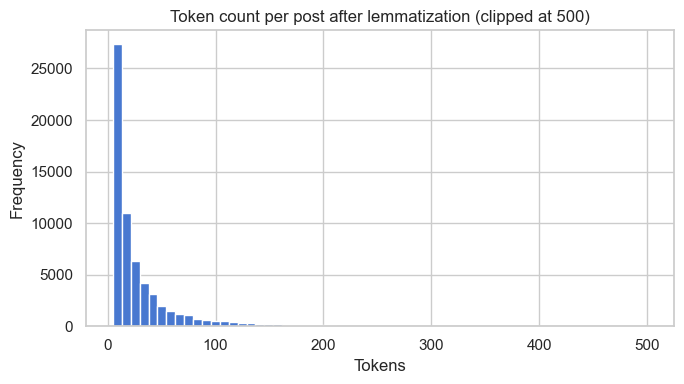

In [13]:
fig, ax = plt.subplots(figsize=(7, 4))
df['token_count'].clip(upper=500).plot(kind='hist', bins=60, ax=ax)
ax.set_title('Token count per post after lemmatization (clipped at 500)')
ax.set_xlabel('Tokens')
plt.tight_layout()
plt.show()

## 6. Temporal Features

Parses `created_utc`, extracts `year_month`, `year`, `month`, and — new in analysis_b — **`date`** (calendar day) and **`day_idx`** (integer 0 → N−1, used as the OLS covariate in `04_temporal.ipynb`).

In [14]:
df['created_utc'] = pd.to_datetime(df['created_utc'], errors='coerce')

n_bad = df['created_utc'].isnull().sum()
if n_bad > 0:
    print(f'Warning: {n_bad} unparseable timestamps — dropping.')
    df = df.dropna(subset=['created_utc']).reset_index(drop=True)

df['year_month'] = df['created_utc'].dt.to_period('M').astype(str)
df['year']       = df['created_utc'].dt.year
df['month']      = df['created_utc'].dt.month
df['date']       = df['created_utc'].dt.normalize()          # midnight-truncated Timestamp
df['day_idx']    = (df['date'] - df['date'].min()).dt.days   # 0-based integer

print(f'Date range : {df["date"].min().date()} → {df["date"].max().date()}')
print(f'Span       : {int(df["day_idx"].max()) + 1} days')
print('Months present:', sorted(df['year_month'].unique()))

Date range : 2025-01-01 → 2025-11-08
Span       : 312 days
Months present: ['2025-01', '2025-02', '2025-03', '2025-04', '2025-05', '2025-06', '2025-07', '2025-08', '2025-09', '2025-10', '2025-11']


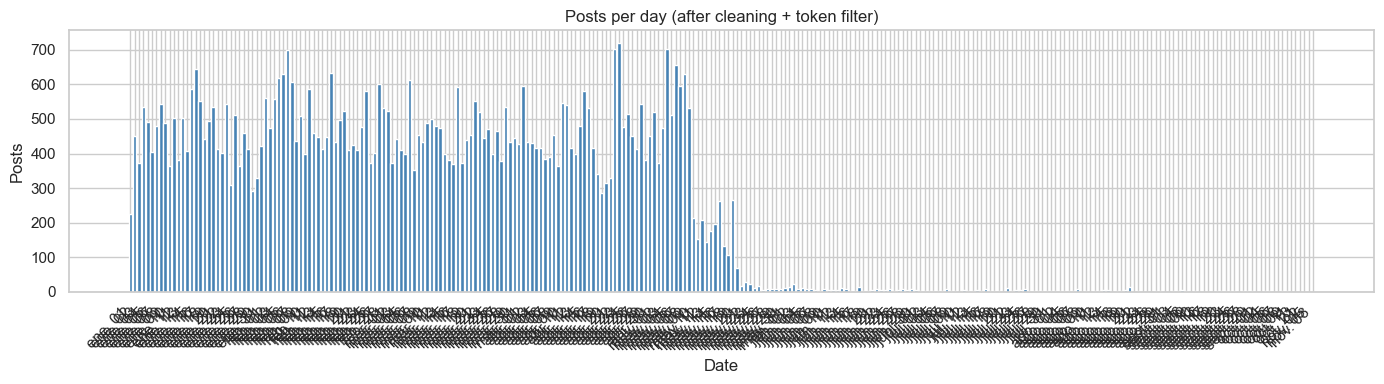

In [15]:
daily_counts = df.groupby('date').size().sort_index()

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(range(len(daily_counts)), daily_counts.values, color='steelblue', width=0.8)
ax.set_xticks(range(len(daily_counts)))
ax.set_xticklabels(
    [d.strftime('%b %d') for d in daily_counts.index], rotation=45, ha='right'
)
ax.set_title('Posts per day (after cleaning + token filter)')
ax.set_xlabel('Date')
ax.set_ylabel('Posts')
plt.tight_layout()
plt.show()

## 7. Write Artifact

Writes `artifacts/posts_clean.parquet`. All analysis_b notebooks read from this file.

| Column | Type | Notes |
|---|---|---|
| `post_id` | str | Reddit post ID |
| `title` | str | Post title |
| `text_raw` | str | Original scraped text |
| `text_clean` | str | Markup-stripped text |
| `text_lemma` | str | Space-joined lemmas |
| `tokens` | list[str] | Lemma token list |
| `token_count` | int | Post length in tokens |
| `score` | float | Upvote score |
| `flair` | str | Post flair |
| `created_utc` | datetime | UTC post time |
| `year_month` | str | e.g. `'2026-02'` |
| `year` | int | |
| `month` | int | |
| `date` | datetime | Calendar day (midnight) |
| `day_idx` | int | Days since first post (0-based) |

In [16]:
SAVE_COLS = [
    'post_id', 'type', 'post_title', 'text_raw', 'text_clean', 'text_lemma',
    'tokens', 'token_count', 'score', 'flair', 
    'created_utc', 'year_month', 'year', 'month', 'date', 'day_idx',
]
SAVE_COLS = [c for c in SAVE_COLS if c in df.columns]

out_path = ARTIFACTS / 'posts_clean.parquet'
df[SAVE_COLS].to_parquet(out_path, index=False)

print(f'Saved {len(df):,} posts → {out_path}')
print(f'Columns : {SAVE_COLS}')
print(f'File size: {out_path.stat().st_size / 1024:.1f} KB')

Saved 63,305 posts → artifacts\posts_clean.parquet
Columns : ['post_id', 'type', 'post_title', 'text_raw', 'text_clean', 'text_lemma', 'tokens', 'token_count', 'score', 'flair', 'created_utc', 'year_month', 'year', 'month', 'date', 'day_idx']
File size: 49308.1 KB
